Zomato Restaurant Data Analysis - Exploratory Data Analysis (EDA)

In [1]:
#importing necessary dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the data
data=pd.read_csv("/content/test_zomato.csv",index_col=0) #first column is just a row index

In [3]:
data.head() #first 5 records by default

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,6304287,Izakaya Kikufuji,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,6300002,Heat - Edsa Shangri-La,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,6318506,Ooma,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,6314302,Sambo Kojin,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.58445,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


Part 1 - Data Understanding & Exploration

In [4]:
data.shape #(rows, columns) -> 9552 rows and 21 columns

(9552, 21)

In [5]:
data.columns #column names present in the dataset

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [6]:
data.info() #datatypes and non-null counts of every column

<class 'pandas.core.frame.DataFrame'>
Index: 9552 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9552 non-null   object 
 1   Restaurant Name       9552 non-null   object 
 2   Country Code          9552 non-null   float64
 3   City                  9552 non-null   object 
 4   Address               9552 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   object 
 8   Latitude              9551 non-null   object 
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   object 
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu  9551

In [7]:
data.dtypes #some columns like 'Average Cost for two' are object(text) but should be numeric

Restaurant ID            object
Restaurant Name          object
Country Code            float64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude                object
Latitude                 object
Cuisines                 object
Average Cost for two     object
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range             float64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                   float64
dtype: object

In [8]:
data.isnull().sum() #missing values per column

Restaurant ID            0
Restaurant Name          0
Country Code             0
City                     0
Address                  0
Locality                 1
Locality Verbose         1
Longitude                1
Latitude                 1
Cuisines                10
Average Cost for two     1
Currency                 1
Has Table booking        1
Has Online delivery      1
Is delivering now        1
Switch to order menu     1
Price range              2
Aggregate rating         2
Rating color             2
Rating text              2
Votes                    2
dtype: int64

In [9]:
data[data['Aggregate rating'].isnull()] #these 2 rows are malformed - a Singapore address had commas that broke the csv and shifted values across columns

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
472,18482938,Super Loco,184.000000,Singapore,The Quayside,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60 Roberston Quay #01-13 238252,"Robertson Quay, Singapore River","Robertson Quay, Singapore River, Singapore",103.839165,1.290083898,"American, Mexican",95,Dollar($),No,No,No,...,4,3.2,Orange,Average,30,NaN,NaN,NaN,NaN,NaN


In [10]:
data.duplicated().sum() #no exact duplicate records in the dataset

np.int64(0)

In [11]:
data.duplicated(subset=['Restaurant ID']).sum() #no duplicate Restaurant IDs either

np.int64(0)

In [12]:
#dropping the 2 malformed rows (they have null Aggregate rating)
data=data.dropna(subset=['Aggregate rating'])
data.shape #now 9550 rows

(9550, 21)

In [13]:
#converting 'Average Cost for two' from object(text) to numeric type
data['Average Cost for two']=pd.to_numeric(data['Average Cost for two'],errors='coerce')

In [14]:
#converting 'Votes' and 'Price range' to numeric as well
data['Votes']=pd.to_numeric(data['Votes'],errors='coerce').astype(int)
data['Price range']=pd.to_numeric(data['Price range'],errors='coerce').astype(int)

In [15]:
data.dtypes #datatypes are corrected now

Restaurant ID            object
Restaurant Name          object
Country Code            float64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude                object
Latitude                 object
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

In [16]:
data.describe() #basic statistical analysis of the numeric columns

,Country Code,Average Cost for two,Price range,Aggregate rating,Votes
count,9550.000000,9550.000000,9550.000000,9550.000000,9550.000000
mean,18.348272,1199.326387,1.804607,2.666314,156.923037
std,56.728197,16122.023220,0.905378,1.516447,430.189709
min,1.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,250.000000,1.000000,2.500000,5.000000
50%,1.000000,400.000000,2.000000,3.200000,31.000000
75%,1.000000,700.000000,2.000000,3.700000,131.000000
max,216.000000,800000.000000,4.000000,4.900000,10934.000000


In [17]:
data['City'].nunique() #number of unique cities present in the dataset

141

In [18]:
data['City'].value_counts().head(1) #New Delhi has the highest number of restaurants (5473)

City
New Delhi    5473
Name: count, dtype: int64

In [19]:
#splitting the multi-cuisine text to find the most frequent single cuisine
cuisines=data['Cuisines'].dropna().str.split(', ').explode().str.strip()
cuisines.value_counts().head(1) #North Indian appears most frequently (3960 listings)

Cuisines
North Indian    3960
Name: count, dtype: int64

Part 2 - Data Analysis

In [20]:
#note: an Aggregate rating of 0 means the restaurant is 'Not rated'
rated=data[data['Aggregate rating']>0] #restaurants that actually have a rating
(data['Aggregate rating']==0).sum() #2148 restaurants are unrated

np.int64(2148)

In [21]:
data['Aggregate rating'].mean() #average rating across all rows (unrated 0s pull it down)

np.float64(2.666314136125654)

In [22]:
rated['Aggregate rating'].mean() #average rating considering only rated restaurants -> ~3.44

np.float64(3.4400567414212375)

In [23]:
data.loc[data['Votes'].idxmax(),['Restaurant Name','City','Votes','Aggregate rating']] #restaurant with the highest number of votes -> Toit, Bangalore

Restaurant Name          Toit
City                Bangalore
Votes                   10934
Aggregate rating          4.8
Name: 728, dtype: object

In [24]:
data['Average Cost for two'].mean() #average cost for two across all restaurants (mixed currency, mostly INR)

np.float64(1199.326387434555)

In [25]:
#comparing average ratings of restaurants that have vs do not have Online Delivery
rated.groupby('Has Online delivery')['Aggregate rating'].mean() #among rated restaurants the ratings are almost the same

Has Online delivery
No     3.467486
Yes    3.381274
Name: Aggregate rating, dtype: float64

In [26]:
#comparing average ratings of restaurants that have vs do not have Table Booking
rated.groupby('Has Table booking')['Aggregate rating'].mean() #restaurants with table booking are rated slightly higher

Has Table booking
No     3.414004
Yes    3.587579
Name: Aggregate rating, dtype: float64

In [27]:
data['City'].value_counts().head(10) #top 10 cities with the highest number of restaurants

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

Part 3 - Data Visualization

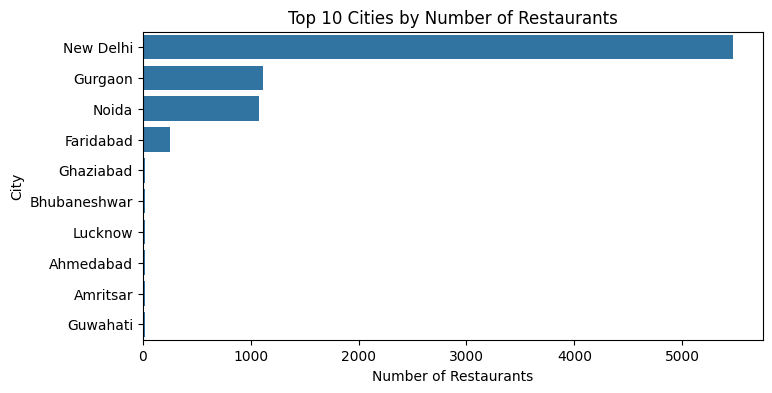

In [28]:
#1. Bar Chart - Top 10 cities with the highest number of restaurants
top_cities=data['City'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_cities.values,y=top_cities.index)
plt.title('Top 10 Cities by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.show()
#New Delhi dominates the dataset followed by Gurgaon and Noida (Delhi NCR region)

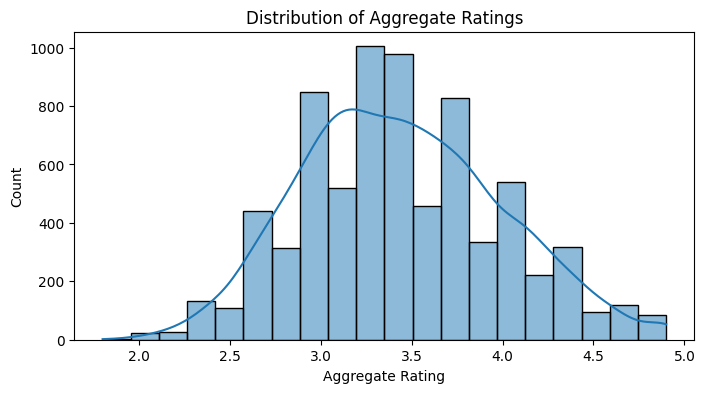

In [29]:
#2. Histogram - Distribution of Aggregate Ratings
plt.figure(figsize=(8,4))
sns.histplot(rated['Aggregate rating'],bins=20,kde=True)
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Count')
plt.show()
#most rated restaurants fall in the 3.0 to 4.0 range (roughly bell shaped)

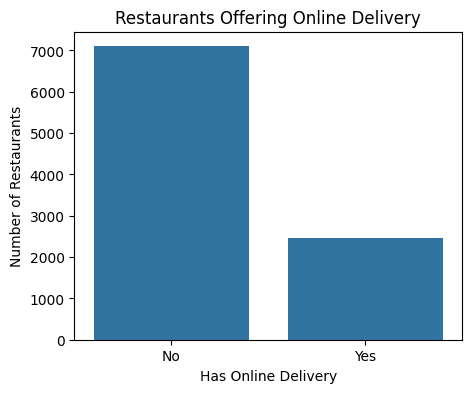

In [30]:
#3. Bar Chart - Number of restaurants offering Online Delivery (Yes/No)
delivery=data['Has Online delivery'].value_counts()
plt.figure(figsize=(5,4))
sns.barplot(x=delivery.index,y=delivery.values)
plt.title('Restaurants Offering Online Delivery')
plt.xlabel('Has Online Delivery')
plt.ylabel('Number of Restaurants')
plt.show()
#only about 26% of restaurants (2451) offer online delivery

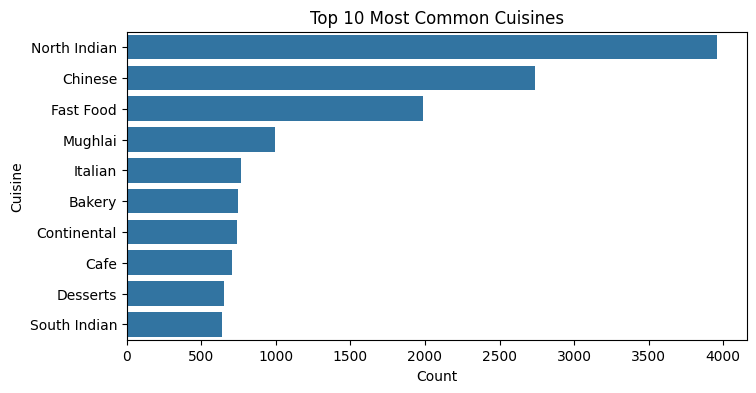

In [31]:
#4. Bar Chart - Top 10 most common cuisines
top_cuisines=cuisines.value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_cuisines.values,y=top_cuisines.index)
plt.title('Top 10 Most Common Cuisines')
plt.xlabel('Count')
plt.ylabel('Cuisine')
plt.show()
#North Indian and Chinese are the most common cuisines

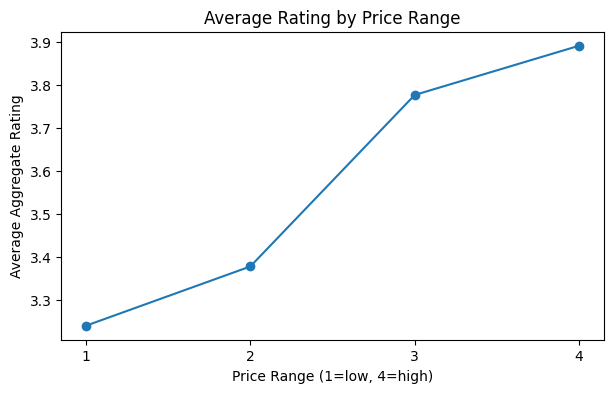

In [32]:
#5. Line Chart - Average restaurant rating by Price Range
price_rating=rated.groupby('Price range')['Aggregate rating'].mean()
plt.figure(figsize=(7,4))
plt.plot(price_rating.index,price_rating.values,marker='o')
plt.title('Average Rating by Price Range')
plt.xlabel('Price Range (1=low, 4=high)')
plt.ylabel('Average Aggregate Rating')
plt.xticks([1,2,3,4])
plt.show()
#average rating increases steadily as the price range increases

Part 4 - Insights & Conclusion

1. New Delhi has the highest restaurant presence (5473 restaurants) - the Delhi NCR region dominates the dataset.
2. North Indian is the most popular cuisine, followed by Chinese and Fast Food.
3. Restaurants with Online Delivery do NOT really have higher ratings - among rated restaurants the averages are almost equal. The higher overall number for delivery is only because most unrated (0) restaurants are non-delivery.
4. Restaurants offering Table Booking receive slightly better ratings (they tend to be higher-end establishments).
5. Learning: real world data needs cleaning (malformed rows, wrong datatypes, 0 = unrated). Simple averages can be misleading, so segmenting rated vs unrated matters. Rating also increases with price range.